# Fine-Tuned BERT Phishing Classifier — Final Test Report

This notebook loads a fine-tuned BERT model and evaluates it on a held-out test set.
Outputs include: Accuracy, ROC-AUC, classification report, confusion matrix, and brief error analysis.

### Imports

In [1]:
import os
import random
import evaluate
import torch

import numpy as np
import pandas as pd
from tqdm import tqdm

from datasets import Dataset,DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

### Reproducibility + device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3080


### Load + split data

In [3]:
# Load and Split Data
data_df = pd.read_csv('Phishing_Email.csv')
train_size = .8
validation_size = .1
test_size = .1

# Uses global Seed for random_state
train_df, temp_df = train_test_split(data_df, train_size = train_size, random_state= SEED)
validation_df, test_df = train_test_split(temp_df, test_size=.5, random_state= SEED)

# Configure Pandas Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.expand_frame_rep', False)


print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)
print()
print("Below is a small sample of what the data we will be using looks like:")

sample_phishing = train_df[train_df['Email Type'] == 'Phishing Email'].sample(n=3, random_state=SEED)
sample_safe = train_df[train_df['Email Type'] == 'Safe Email'].sample(n=3, random_state=SEED)

print(pd.concat([sample_phishing, sample_safe]))

Training Data shape: (14920, 3)
Validation Data shape: (1865, 3)
Testing Data shape: (1865, 3)

Below is a small sample of what the data we will be using looks like:
      Unnamed: 0                                                             Email Text      Email Type
6199        6199  sorry , one more thing cheating adult personals get laid now . rea...  Phishing Email
5658        5658  payment representative dear sir / madam , i am mr . liu peijin , m...  Phishing Email
5466        5466  When Economy goes down, WE go UP !$3000 COMMISSION per Sale for YO...  Phishing Email
7321        7322  fifth annual graduate romanic association at the u . of penn . * *...      Safe Email
3140        3140  december conference preliminary announcement first international w...      Safe Email
3510        3510  re : term project : brian , no problem . vince " brian corbett nel...      Safe Email


### Convert to HuggingFace Datasets

In [4]:
torch.cuda.empty_cache()
print("CPU/GPU Cache Cleared")

train_df["Email Text"] = train_df["Email Text"].fillna("").astype(str)
validation_df["Email Text"] = validation_df["Email Text"].fillna("").astype(str)
test_df["Email Text"] = test_df["Email Text"].fillna("").astype(str)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print("Dataset converted to HuggingFace")

CPU/GPU Cache Cleared
Dataset converted to HuggingFace


### Load tokenizer + model

In [5]:
# Base tokenizer (same as training)
model_path = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Paths to saved checkpoints (reuse from test.ipynb)
base_path = os.path.abspath("./BERT/final_phishing_model")

path_v2 = os.path.join(base_path, "checkpoint-1866")
path_v3 = os.path.join(base_path, "checkpoint-2799")

print("Checkpoint v2:", path_v2)
print("Checkpoint v3:", path_v3)

# Load the final checkpoint (v3)
model = AutoModelForSequenceClassification.from_pretrained(path_v3)

print("Loaded fine-tuned BERT model from:", path_v3)

Checkpoint v2: C:\Users\aidan\CS_175\E-ML\BERT\final_phishing_model\checkpoint-1866
Checkpoint v3: C:\Users\aidan\CS_175\E-ML\BERT\final_phishing_model\checkpoint-2799


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded fine-tuned BERT model from: C:\Users\aidan\CS_175\E-ML\BERT\final_phishing_model\checkpoint-2799


### Preprocess + tokenize

In [6]:
def preprocess_function(examples):
    result = tokenizer(examples["Email Text"], truncation=True, padding=True)

    label_map = {"Safe Email": 0, "Phishing Email": 1}
    result["labels"] = [label_map[l] for l in examples["Email Type"]]

    return result

tokenized_train_data = train_dataset.map(preprocess_function, batched=True)
tokenized_validation_data = validation_dataset.map(preprocess_function, batched=True)
tokenized_test_data = test_dataset.map(preprocess_function, batched=True)

print("Tokenized train/val/test")

Map:   0%|          | 0/14920 [00:00<?, ? examples/s]

Map:   0%|          | 0/1865 [00:00<?, ? examples/s]

Map:   0%|          | 0/1865 [00:00<?, ? examples/s]

Tokenized train/val/test


### Metrics (Accuracy + ROC-AUC)

In [7]:
accuracy = evaluate.load("accuracy")
auc_score = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    positive_class_probs = probabilities[:, 1]

    auc = np.round(
        auc_score.compute(prediction_scores=positive_class_probs, references=labels)["roc_auc"],
        3
    )

    predicted_classes = np.argmax(predictions, axis=1)
    acc = np.round(
        accuracy.compute(predictions=predicted_classes, references=labels)["accuracy"],
        3
    )

    return {"Accuracy": acc, "AUC": auc}

### Data collator

In [8]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Data collator ready.")

Data collator ready.


### Eval-only TrainingArguments

In [9]:
eval_args = TrainingArguments(
    output_dir="./temp_eval",
    report_to="none"
)

print("Eval args ready.")

Eval args ready.


### Build Trainer

In [10]:
trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


### Evaluate on TEST

In [11]:
test_results = trainer.evaluate(tokenized_test_data)

print("=== FINAL TEST RESULTS (checkpoint-2799) ===")
print(test_results)

=== FINAL TEST RESULTS (checkpoint-2799) ===
{'eval_loss': 0.06719517707824707, 'eval_model_preparation_time': 0.003, 'eval_Accuracy': 0.981, 'eval_AUC': 0.998, 'eval_runtime': 16.7738, 'eval_samples_per_second': 111.186, 'eval_steps_per_second': 13.95}


### Predict on TEST (logits → y_pred)

In [12]:
pred_out = trainer.predict(tokenized_test_data)

logits = pred_out.predictions
y_true = np.array(tokenized_test_data["labels"])
y_pred = np.argmax(logits, axis=1)

print("Predictions complete.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

Predictions complete.
y_true shape: (1865,)
y_pred shape: (1865,)


### Confusion Matrix

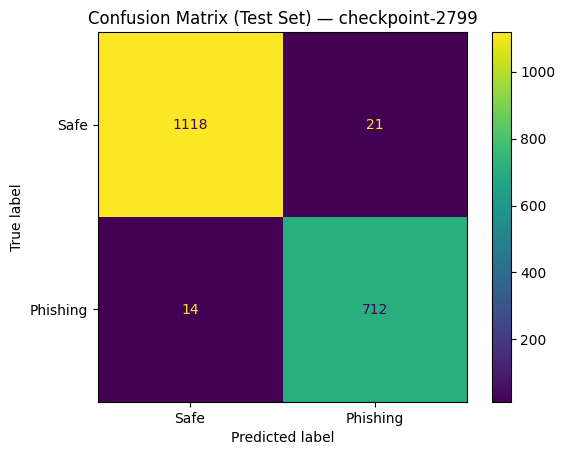

In [13]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Phishing"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set) — checkpoint-2799")
plt.show()

### Classification report + quick preview

In [14]:
print("=== Classification Report (Test Set) ===")
print(classification_report(y_true, y_pred, target_names=["Safe", "Phishing"], digits=4))

# Optional: attach predictions to the original test_df for a quick sanity check
preview_df = test_df.copy().reset_index(drop=True)
preview_df["y_true"] = y_true
preview_df["y_pred"] = y_pred
display(preview_df[["Email Type", "y_true", "y_pred", "Email Text"]].head(10))

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

        Safe     0.9876    0.9816    0.9846      1139
    Phishing     0.9714    0.9807    0.9760       726

    accuracy                         0.9812      1865
   macro avg     0.9795    0.9811    0.9803      1865
weighted avg     0.9813    0.9812    0.9812      1865



,Email Type,y_true,y_pred,Email Text
0,Phishing Email,1,1,\nATTN:I PRESUME THIS MAIL WILL NOT BE A SURPRISE TO YOU.\nI AM AN...
1,Phishing Email,1,1,FIND PROSPECTS FOR YOUR BIZ/PRODUCTS...FAST !!DO YOU KNOW HOW TO U...
2,Safe Email,0,0,re : kid ' s center i ' ve confirmed that the 1 / 2 block on the e...
3,Safe Email,0,0,"Hi.""Kevin Worthington"" wrote:> into /home/dude/redhat etc. by run..."
4,Phishing Email,1,1,"real - time online trade ! hello anitacimmino , i just found a sit..."
5,Safe Email,0,0,open season notices as today is the deadline for our open season r...
6,Safe Email,0,0,new books : sociolinguistics john benjamins publishing would like ...
7,Safe Email,0,0,cuny ' 98 conference below you will find information regarding reg...
8,Phishing Email,1,1,uptick sharess mnei - the best small cap stock in 20 o 5 just keep...
9,Safe Email,0,0,">>>>> ""J"" == Jon O writes: J> Has anyone considered the fact t..."


Running BERT inference on CEAS_08...


100%|███████████████████████████████████████████████████████████████████████████| 39154/39154 [06:24<00:00, 101.83it/s]



CEAS_08 (BERT Evaluation)
Shape: (39154, 9)
                precision    recall  f1-score   support

    Safe Email     0.8190    0.9346    0.8730     17312
Phishing Email     0.9416    0.8363    0.8859     21842

      accuracy                         0.8798     39154
     macro avg     0.8803    0.8855    0.8794     39154
  weighted avg     0.8874    0.8798    0.8802     39154



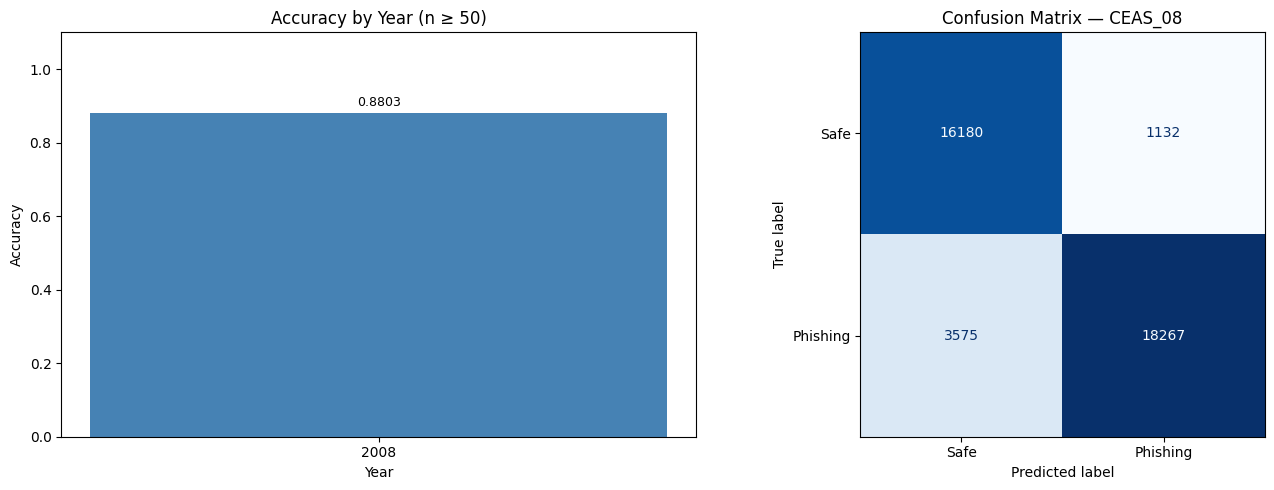

Running BERT inference on Nigerian_5...


100%|██████████████████████████████████████████████████████████████████████████████| 6331/6331 [01:13<00:00, 85.82it/s]



Nigerian_5 (BERT Evaluation)
Shape: (6331, 9)
                precision    recall  f1-score   support

    Safe Email     0.9910    0.9537    0.9720      2999
Phishing Email     0.9597    0.9922    0.9757      3332

      accuracy                         0.9739      6331
     macro avg     0.9753    0.9729    0.9738      6331
  weighted avg     0.9745    0.9739    0.9739      6331



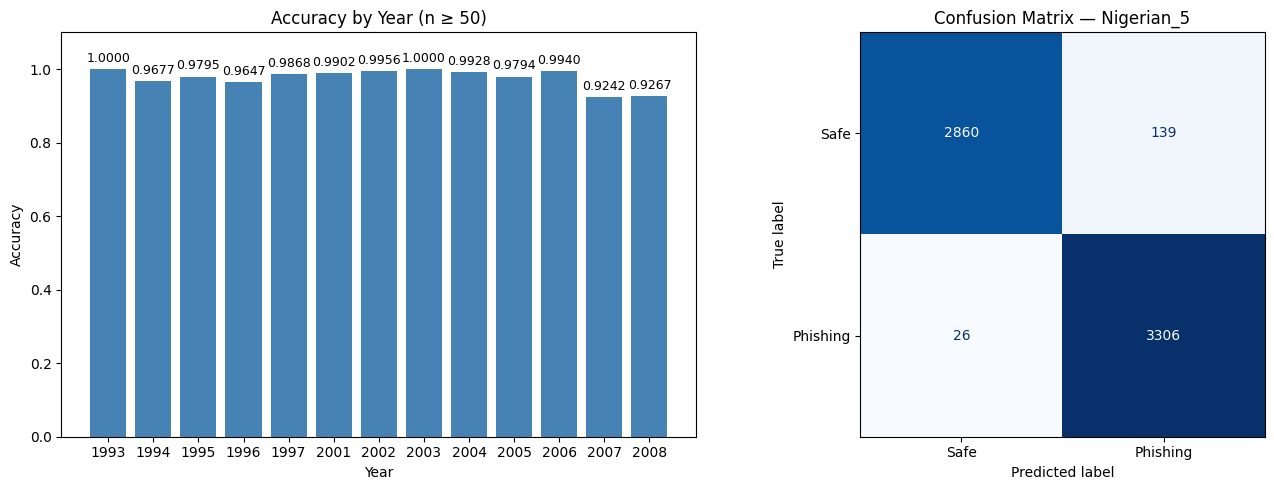

Running BERT inference on Nazario_5...


100%|██████████████████████████████████████████████████████████████████████████████| 3065/3065 [00:42<00:00, 71.88it/s]


Nazario_5 (BERT Evaluation)
Shape: (3065, 9)
                precision    recall  f1-score   support

    Safe Email     0.8083    0.9500    0.8734      1500
Phishing Email     0.9424    0.7840    0.8559      1565

      accuracy                         0.8653      3065
     macro avg     0.8753    0.8670    0.8647      3065
  weighted avg     0.8768    0.8653    0.8645      3065



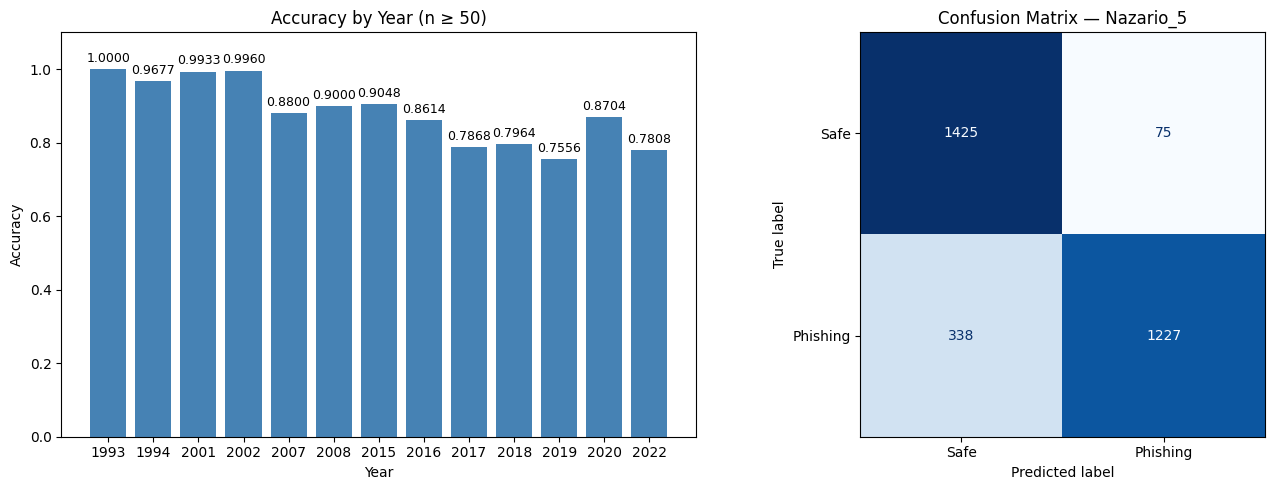

Running BERT inference on Nazario...


100%|██████████████████████████████████████████████████████████████████████████████| 1565/1565 [00:26<00:00, 59.10it/s]
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labe


Nazario (BERT Evaluation)
Shape: (1565, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.7840    0.8789      1565

      accuracy                         0.7840      1565
     macro avg     0.5000    0.3920    0.4395      1565
  weighted avg     1.0000    0.7840    0.8789      1565



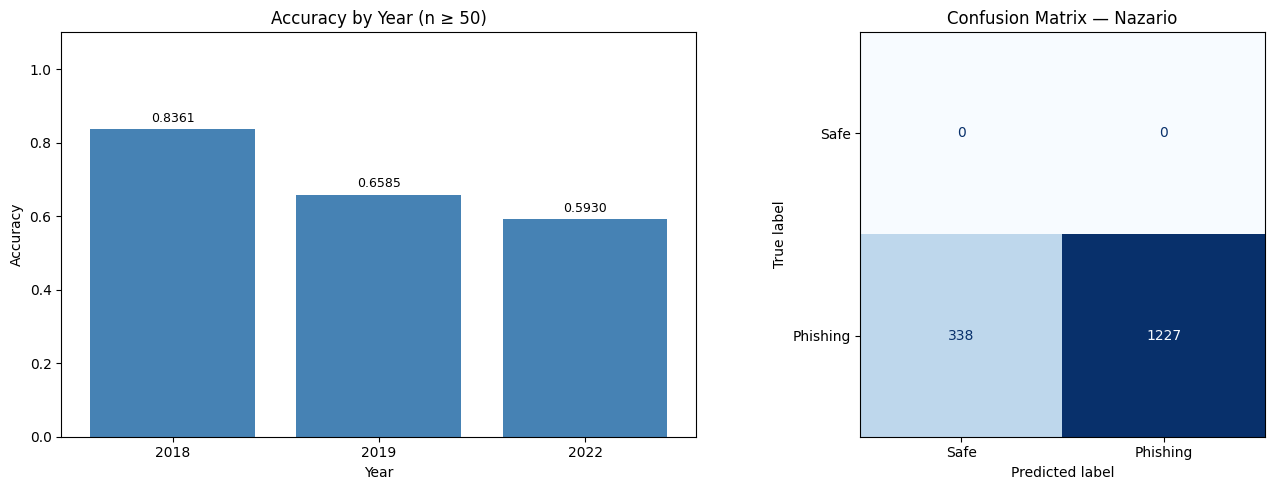

Running BERT inference on SpamAssasin...


100%|██████████████████████████████████████████████████████████████████████████████| 5809/5809 [01:06<00:00, 87.90it/s]



SpamAssasin (BERT Evaluation)
Shape: (5809, 9)
                precision    recall  f1-score   support

    Safe Email     0.9926    0.9868    0.9897      4091
Phishing Email     0.9690    0.9825    0.9757      1718

      accuracy                         0.9855      5809
     macro avg     0.9808    0.9847    0.9827      5809
  weighted avg     0.9856    0.9855    0.9856      5809



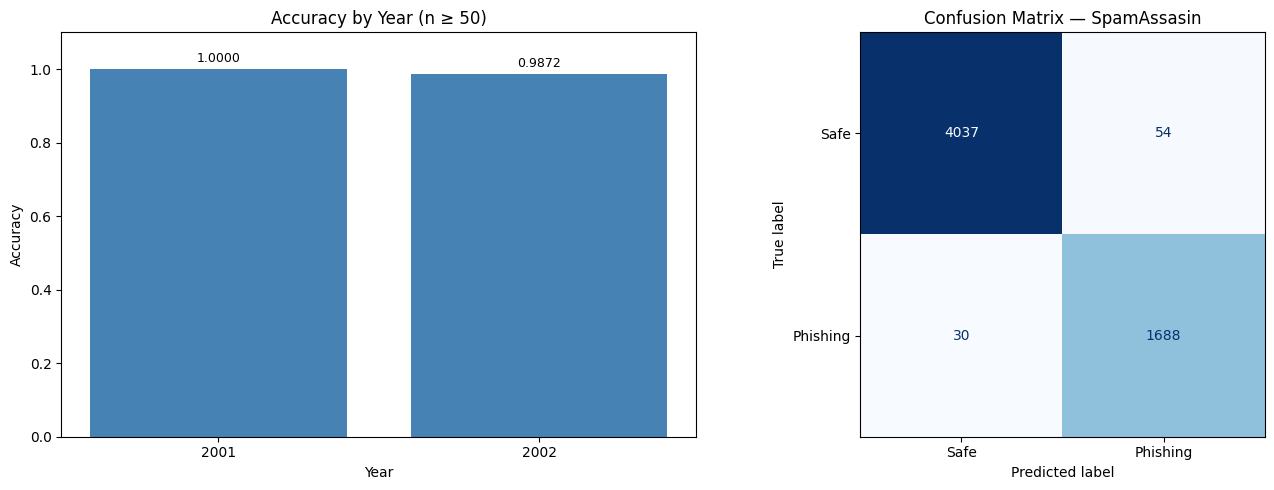

Running BERT inference on Nigerian Fraud...


100%|██████████████████████████████████████████████████████████████████████████████| 3332/3332 [00:39<00:00, 83.67it/s]
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aidan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labe


Nigerian Fraud (BERT Evaluation)
Shape: (3332, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.9922    0.9961      3332

      accuracy                         0.9922      3332
     macro avg     0.5000    0.4961    0.4980      3332
  weighted avg     1.0000    0.9922    0.9961      3332



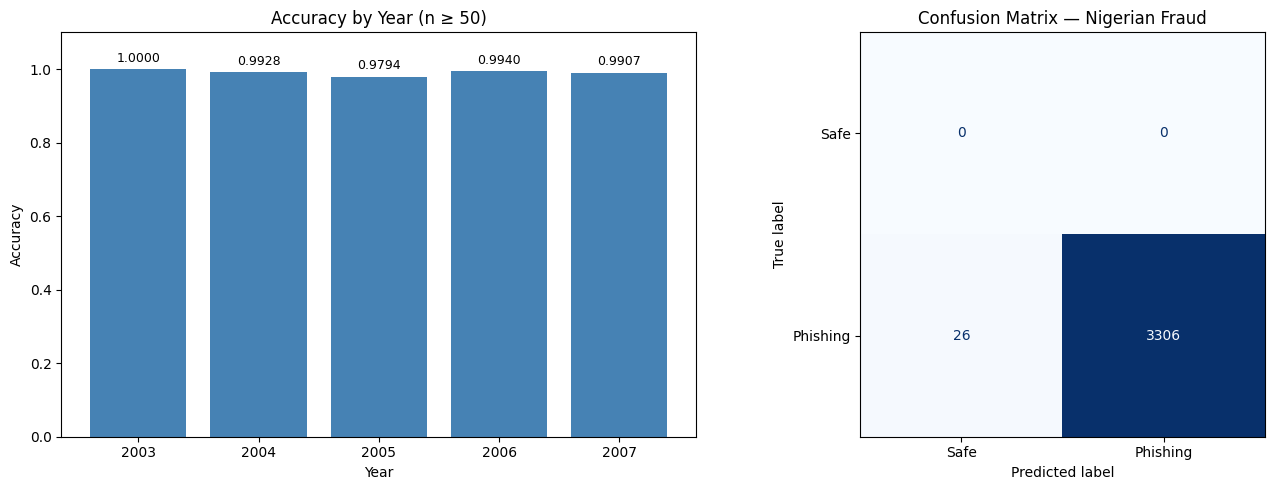

In [15]:
def evaluate_dataset_bert(path, title, min_n=50):
    df = pd.read_csv(path)
    
    # 1. Handle Date Column
    has_date = 'date' in df.columns
    if has_date:
        df['year'] = pd.to_datetime(df['date'], errors='coerce', utc=True).dt.year.fillna(-1).astype(int)
    
    # 2. Pre-process and Predict using BERT
    # We use a simple loop or map to handle tokenization and inference
    def get_bert_prediction(text):
        # Ensure text is a string
        text = str(text) if pd.notnull(text) else ""
        # Tokenize
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
        # Predict
        with torch.no_grad():
            logits = model(**inputs).logits
        return torch.argmax(logits, dim=-1).item()

    print(f"Running BERT inference on {title}...")
    # tqdm adds a progress bar so you can track the evaluation
    df['pred'] = [get_bert_prediction(t) for t in tqdm(df['body'])]
    df['label'] = df['label'].astype(int)

    # 3. Print Results
    print(f"\n{'='*50}\n{title} (BERT Evaluation)\n{'='*50}")
    print(f"Shape: {df.shape}")
    print(classification_report(df['label'], df['pred'],
          target_names=['Safe Email', 'Phishing Email'], digits=4))

    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if has_date:
        yr_df = pd.DataFrame([
            {'year': y, 'n': (m := df['year'] == y).sum(),
             'accuracy': accuracy_score(df.loc[m, 'label'], df.loc[m, 'pred'])}
            for y in sorted(df['year'].unique()) if y != -1
        ])
        yr_df = yr_df[yr_df['n'] >= min_n]
        if not yr_df.empty:
            bars = axes[0].bar(yr_df['year'].astype(str), yr_df['accuracy'], color='steelblue')
            axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
            axes[0].set_ylim(0, 1.1)
        axes[0].set_title(f'Accuracy by Year (n ≥ {min_n})')
        axes[0].set_xlabel('Year')
        axes[0].set_ylabel('Accuracy')
    else:
        axes[0].text(0.5, 0.5, 'No date column available', ha='center', va='center')
        axes[0].set_title('Accuracy by Year')

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(df['label'], df['pred']),
        display_labels=['Safe', 'Phishing']
    ).plot(ax=axes[1], colorbar=False, cmap=plt.cm.Blues)
    axes[1].set_title(f'Confusion Matrix — {title}')
    
    plt.tight_layout()
    plt.show()
    return df

# Run the updated evaluations
# Ensure your 'model' (Epoch 3) and 'tokenizer' are loaded before running
ceas_df = evaluate_dataset_bert("CEAS_08.csv", "CEAS_08")
nigerian5_df = evaluate_dataset_bert("Nigerian_5.csv", "Nigerian_5")
nazario5_df = evaluate_dataset_bert("Nazario_5.csv", "Nazario_5")
nazario_df = evaluate_dataset_bert("Nazario.csv", "Nazario")
spam_df = evaluate_dataset_bert("SpamAssasin.csv","SpamAssasin")
nigerian_df = evaluate_dataset_bert("Nigerian_Fraud.csv", "Nigerian Fraud")